# Low-Rank Adaptation (LoRA) for Emotion Classification


---
### Team Members:
- **Chouchou Ibtissam**
- **Fatma Ines Manel Boumazouza**
- **Bochra Lafifi**
- **Fatima Al Harake**

---

### **Project Description**

In this notebook, we implement and evaluate **Low-Rank Adaptation (LoRA)** from scratch based on the paper:

> *Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., & Chen, W. (2021). LoRA: Low-Rank Adaptation of Large Language Models. arXiv preprint arXiv:2106.09685.*

We implement LoRA **from scratch** and apply it to **BERT** for emotion classification using the **DAIR-AI Emotion** dataset from Hugging Face.  
Then, we compare LoRA with BERT with full training.


# **1. Imports**

Import all necessary libraries: PyTorch, Transformers, datasets, and evaluation metrics.

In [ ]:
import time
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import (
    BertModel,
    BertTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from peft import get_peft_model, PrefixTuningConfig, TaskType
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
import os
os.environ["WANDB_DISABLED"] = "true"

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


# **2. Dataset Loading & Preprocessing**

### **Loading the Dataset**

Load the dair-ai/emotion dataset from Hugging Face for emotion classification.

In [ ]:
# Load emotion dataset
dataset = load_dataset("dair-ai/emotion")
dataset["train"] = dataset["train"].shuffle(seed=42).select(range(3000))
dataset["validation"] = dataset["validation"].shuffle(seed=42).select(range(500))
dataset["test"] = dataset["test"].shuffle(seed=42).select(range(500))

print(f"Train: {len(dataset['train'])} samples")
print(f"Validation: {len(dataset['validation'])} samples")
print(f"Test: {len(dataset['test'])} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 3000 samples
Validation: 500 samples
Test: 500 samples


### **Tokenizing the Dataset**

Apply BERT tokenizer to transform text into model-ready input tensors.

In [ ]:
# Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

def preprocess(batch, tokenizer):
    return tokenizer(batch['text'], truncation=True, padding="max_length", max_length=128)

# Tokenize dataset
tokenized_dataset = dataset.map(
    preprocess,
    fn_kwargs={"tokenizer": tokenizer},
    batched=True
).rename_column("label", "labels")

tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
print(" Dataset tokenized")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

 Dataset tokenized


# **3. Evaluation Metrics Function**

Define the metrics (accuracy and F1 score) to evaluate model performance on the emotion classification task.

In [ ]:
# Compute metrics function (used by all models)
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

# **4. Model 1: BERT + LoRA**
## **4.1 LoRA Layer Implementation**
LoRA (Low-Rank Adaptation) freezes pre-trained model weights and injects trainable rank decomposition matrices into each layer. For a pre-trained weight matrix $W_0 \in \mathbb{R}^{d \times k}$, LoRA constrains its update with a low-rank decomposition:

$$W = W_0 + \Delta W = W_0 + BA$$

where:
- $B \in \mathbb{R}^{d \times r}$ is randomly initialized
- $A \in \mathbb{R}^{r \times k}$ is zero-initialized
- $r \ll \min(d, k)$ is the rank

### **Forward Pass**

During the forward pass, for input $x$:

$$h = W_0 x + \Delta W x = W_0 x + BAx$$

The output is scaled by $\frac{\alpha}{r}$ where $\alpha$ is a constant:

$$h = W_0 x + \frac{\alpha}{r} BAx$$

This reduces the number of trainable parameters and memory usage while keeping good performance.

The following diagram illustrates the LoRA architecture and low-rank decomposition process:

![LoRA Overview](https://coralogix.com/wp-content/uploads/2025/03/rblog3-03.png)

**Figure**: Low-Rank Adaptation visualization showing how the weight update $\Delta W$ is decomposed into low-rank matrices $B$ and $A$, where:
- $W$ (left): Pre-trained frozen weight matrix
- $\Delta W = BA$ (right): Low-rank trainable adaptation
- $B$ is initialized from normal distribution
- $A$ is initialized to zero

In [ ]:
class LoRALayer(nn.Module):
    """LoRA Layer: h = W₀x + BAx"""
    def __init__(self, original_layer, r=8, alpha=16):
        super().__init__()
        if r < 0:
            raise ValueError("Rank must be a non-negative integer")

        self.original_layer = original_layer
        self.r = r
        self.scaling = alpha / r

        d_model_in = original_layer.in_features
        d_model_out = original_layer.out_features

        self.lora_A = nn.Parameter(torch.zeros(d_model_in, r))
        self.lora_B = nn.Parameter(torch.zeros(r, d_model_out))

        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        original_output = self.original_layer(x)
        lora_output = (x @ self.lora_A @ self.lora_B) * self.scaling
        return original_output + lora_output

## **4.2 BERT + LoRA Model**

Create a custom BERT model with LoRA layers:
- Inject LoRA into attention matrices (Query, Key, Value)
- Freeze all BERT weights except LoRA parameters
- Add classification head for emotion prediction

Formula: $h = W_0 x + \frac{\alpha}{r} BAx$ where only $B$ and $A$ are trainable.

In [ ]:
class BertLoRAForSequenceClassification(nn.Module):
    def __init__(self, model, num_labels=6, r=8, alpha=16):
        super().__init__()
        self.bert = model
        self.num_labels = num_labels
        self.r = r
        self.alpha = alpha

        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

        self._inject_lora()
        self._freeze_bert()

    def _inject_lora(self):
        for layer in self.bert.encoder.layer:
            attention = layer.attention.self
            attention.query = LoRALayer(attention.query, self.r, self.alpha)
            attention.key = LoRALayer(attention.key, self.r, self.alpha)
            attention.value = LoRALayer(attention.value, self.r, self.alpha)

    def _freeze_bert(self):
        for param in self.bert.parameters():
            param.requires_grad = False
        for module in self.bert.modules():
            if isinstance(module, LoRALayer):
                module.lora_A.requires_grad = True
                module.lora_B.requires_grad = True

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {'loss': loss, 'logits': logits}

    def print_trainable_params(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"Paramètres totaux:        {total:,}")
        print(f"Paramètres entraînables:  {trainable:,}")
        return trainable, total

## **4.3 Train LoRA with Hyperparameter Tuning**

### **LoRA Training Function**
Train the LoRA model with specified hyperparameters and return the trainer with training time.

In [ ]:
def train_lora(model, dataset, batch_size=16, epochs=10, output_dir='./results_lora'):
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=3e-4,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        logging_steps=50,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset['train'],
        eval_dataset=dataset['validation'],
        compute_metrics=compute_metrics
    )

    start_time = time.time()
    trainer.train()
    training_time = time.time() - start_time

    return trainer, training_time

### **Hyperparameter Tuning for LoRA**

Test different LoRA configurations to find the optimal setup:
- **Rank (r)**: 2, 8, 16
- **Epochs**: 5, 10
- **Batch size**: 16, 32

Train all combinations and select the best model based on validation accuracy.

In [ ]:
# Hyperparameter tuning for LoRA
r_values = [2, 8, 16]
epochs_values = [5, 10]
batch_size_values = [16, 32]

combinations = list(itertools.product(r_values, epochs_values, batch_size_values))
print(f"Testing {len(combinations)} combinations\n")

results_lora = []

for idx, (r, epochs, batch_size) in enumerate(combinations, 1):
    print(f"\n[{idx}/{len(combinations)}] r={r}, epochs={epochs}, batch_size={batch_size}")

    bert_base = BertModel.from_pretrained('bert-base-uncased')
    model_lora = BertLoRAForSequenceClassification(bert_base, num_labels=6, r=r, alpha=16)
    model_lora.print_trainable_params()

    output_dir = f'./results_r{r}_e{epochs}_bs{batch_size}'
    trainer, train_time = train_lora(model_lora, tokenized_dataset, batch_size, epochs, output_dir)

    log_history = trainer.state.log_history
    val_metrics = [x for x in log_history if 'eval_loss' in x][-1]

    results_lora.append({
        'r': r, 'epochs': epochs, 'batch_size': batch_size,
        'val_accuracy': val_metrics['eval_accuracy'],
        'val_f1': val_metrics['eval_f1'],
        'training_time': train_time
    })

    print(f"Acc: {val_metrics['eval_accuracy']:.4f}, F1: {val_metrics['eval_f1']:.4f}, Time: {train_time:.2f}s")

    del model_lora, trainer, bert_base
    torch.cuda.empty_cache()

# Get best model
df_lora = pd.DataFrame(results_lora).sort_values('val_accuracy', ascending=False)
# Sauvegarder CSV
df_lora.to_csv('hyperparameter_tuning_results.csv', index=False)
print("\n CSV sauvegardé: hyperparameter_tuning_results.csv")

best = df_lora.iloc[0]
print(f"\n Best LoRA: r={int(best['r'])}, epochs={int(best['epochs'])}, batch_size={int(best['batch_size'])}")
print(f"  Accuracy: {best['val_accuracy']:.4f}, Time: {best['training_time']:.2f}s")

Testing 12 combinations


[1/12] r=2, epochs=5, batch_size=16


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Paramètres totaux:        109,597,446
Paramètres entraînables:  115,206


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.223100,1.143599,0.562000,0.435940
2,1.051400,1.101929,0.622000,0.549775
3,0.937500,0.907860,0.682000,0.623398
4,0.858700,0.825253,0.708000,0.668556
5,0.746600,0.796161,0.712000,0.674642


...

Acc: 0.8780, F1: 0.8765, Time: 214.32s

[12/12] r=16, epochs=10, batch_size=32


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Paramètres totaux:        110,371,590
Paramètres entraînables:  889,350


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.530700,1.226471,0.560000,0.448012
2,1.039000,0.880612,0.680000,0.623803
3,0.745100,0.714581,0.740000,0.699519
4,0.526700,0.598312,0.786000,0.772503
5,0.368200,0.596739,0.800000,0.791420
6,0.325300,0.505218,0.826000,0.819786
7,0.249800,0.484778,0.860000,0.859620
8,0.230900,0.492981,0.880000,0.879342
9,0.196100,0.483516,0.866000,0.863795
10,0.190600,0.480429,0.866000,0.864501


Acc: 0.8660, F1: 0.8645, Time: 217.87s

 CSV sauvegardé: hyperparameter_tuning_results.csv

 Best LoRA: r=16, epochs=10, batch_size=16
  Accuracy: 0.8780, Time: 214.32s


# **5. Model N°2: Full Fine-tuning**

### **Full Fine-Tuning Model Architecture**

Standard BERT model for sequence classification where **all parameters are trainable** (baseline for comparison with LoRA).

In [ ]:
class BertForSequenceClassification(nn.Module):
    def __init__(self, model, num_labels=6):
        super().__init__()
        self.bert = model
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {'loss': loss, 'logits': logits}

    def print_trainable_params(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"Paramètres totaux:        {total:,}")
        print(f"Paramètres entraînables:  {trainable:,}")
        return trainable, total

### **Training Full Fine-Tuning Model**

Train BERT with all ~110M parameters trainable (baseline comparison) using the same epochs as the best LoRA configuration.

In [ ]:
# Train Full Fine-tuning
print("Training Full Fine-tuning.")
bert_model = BertModel.from_pretrained('bert-base-uncased')
model_full = BertForSequenceClassification(bert_model, num_labels=6)
model_full.print_trainable_params()

training_args = TrainingArguments(
    output_dir='./results_full',
    num_train_epochs=int(best['epochs']),
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
)

trainer_full = Trainer(
    model=model_full,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics
)

start_time = time.time()
trainer_full.train()
time_full = time.time() - start_time

print(f"\n Full Fine-tuning complete: {time_full:.2f}s")

Training Full Fine-tuning.


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Paramètres totaux:        109,486,854
Paramètres entraînables:  109,486,854


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.624900,1.614891,0.268000,0.113287
2,1.589700,1.617086,0.352000,0.183290
3,1.608400,1.615580,0.268000,0.113287
4,1.627700,1.595043,0.352000,0.183290
5,1.627500,1.586475,0.352000,0.183290
6,1.590600,1.600859,0.352000,0.183290
7,1.568000,1.585975,0.352000,0.183290
8,1.585800,1.604385,0.352000,0.183290
9,1.592100,1.597404,0.352000,0.183290
10,1.560100,1.591750,0.352000,0.183290



 Full Fine-tuning complete: 374.09s


# **6. Comparison & Results**

We compare between the following approaches:

1. **Full Training**  
   All BERT parameters are updated during training.

3. **LoRA (paper's Method)**  
   Only low-rank matrices are trained, and the original model weights are frozen.


## **6.1 Training Comparison**

### **Retraining Best LoRA Model and Final Comparison**

Retrain the best LoRA configuration and compare it with Full Fine-Tuning in terms of accuracy, F1 score, training time, and number of trainable parameters.


In [ ]:
# Retrain best LoRA model
print("Retraining best LoRA model.")
bert_base = BertModel.from_pretrained('bert-base-uncased')
best_lora_model = BertLoRAForSequenceClassification(
    bert_base, num_labels=6, r=int(best['r']), alpha=16
)
trainer_lora, time_lora = train_lora(
    best_lora_model, tokenized_dataset,
    batch_size=int(best['batch_size']),
    epochs=int(best['epochs'])
)

# Gather all trainers
trainers = {
    'LoRA': trainer_lora,
    'Full Fine-tuning': trainer_full,
}

training_times = {
    'LoRA': time_lora,
    'Full Fine-tuning': time_full,
}

# Create comparison table
comparison_data = []
for name, trainer in trainers.items():
    log_history = trainer.state.log_history
    val_metrics = [x for x in log_history if 'eval_loss' in x][-1]

    trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in trainer.model.parameters())

    comparison_data.append({
        'Model': name,
        'Training Time (s)': training_times[name],
        'Val Accuracy': val_metrics['eval_accuracy'],
        'Val F1': val_metrics['eval_f1'],
        'Trainable Params': trainable,
        'Total Params': total,
    })

df_comparison = pd.DataFrame(comparison_data)

Retraining best LoRA model.


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.169200,0.996768,0.634000,0.529768
2,0.771000,0.710351,0.756000,0.712394
3,0.463400,0.535939,0.818000,0.806024
4,0.404500,0.482655,0.840000,0.833466
5,0.250400,0.507006,0.870000,0.865792
6,0.238400,0.516106,0.866000,0.862879
7,0.176600,0.472056,0.882000,0.880644
8,0.139200,0.493270,0.894000,0.893652
9,0.119400,0.495893,0.900000,0.900204
10,0.114600,0.493572,0.902000,0.902306


### **Results Table**

The final comparison table with training metrics for all methods.

In [ ]:
df_table = df_comparison.copy()

df_table["Training Time (s)"] = df_table["Training Time (s)"].round(1)
df_table["Val Accuracy"] = df_table["Val Accuracy"].round(3)
df_table["Val F1"] = df_table["Val F1"].round(3)

print("\nTRAINING COMPARISON\n")
print(tabulate(
    df_table,
    headers="keys",
    tablefmt="grid",
    showindex=False
))


TRAINING COMPARISON

+------------------+---------------------+----------------+----------+--------------------+----------------+
| Model            |   Training Time (s) |   Val Accuracy |   Val F1 |   Trainable Params |   Total Params |
+==================+=====================+================+==========+====================+================+
| LoRA             |               218.7 |          0.902 |    0.902 |             889350 |      110371590 |
+------------------+---------------------+----------------+----------+--------------------+----------------+
| Full Fine-tuning |               374.1 |          0.352 |    0.183 |          109486854 |      109486854 |
+------------------+---------------------+----------------+----------+--------------------+----------------+


### **Visualization**

Plot training loss, validation loss, and validation accuracy across epochs to compare LoRA vs Full Fine-Tuning.


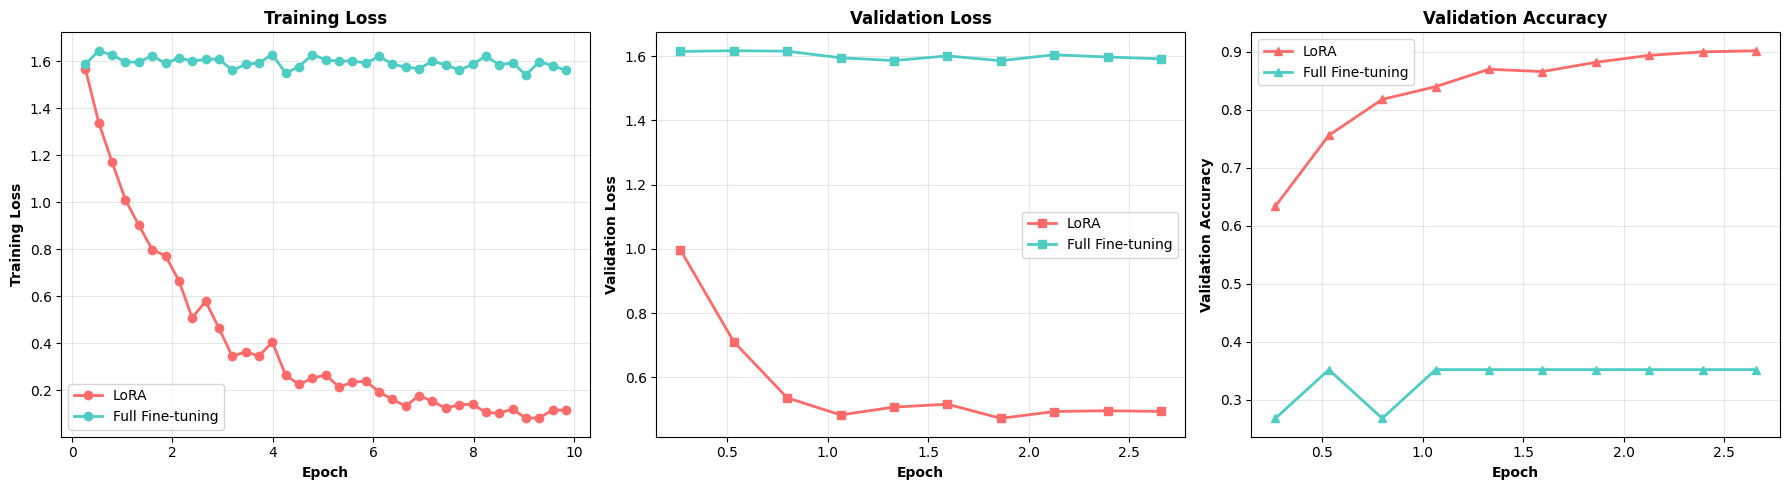

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {
    'LoRA': '#FF6B6B',
    'Full Fine-tuning': '#4ECDC4',
}

for name, trainer in trainers.items():
    log_history = trainer.state.log_history

    epochs = []
    train_losses = []
    val_losses = []
    val_accs = []

    for entry in log_history:
        if 'epoch' in entry:
            if 'loss' in entry:
                epochs.append(entry['epoch'])
                train_losses.append(entry['loss'])
            if 'eval_loss' in entry:
                val_losses.append(entry['eval_loss'])
                val_accs.append(entry['eval_accuracy'])

    color = colors[name]

    if train_losses:
        axes[0].plot(epochs, train_losses, marker='o', label=name, color=color, linewidth=2)
    if val_losses:
        axes[1].plot(epochs[:len(val_losses)], val_losses, marker='s', label=name, color=color, linewidth=2)
    if val_accs:
        axes[2].plot(epochs[:len(val_accs)], val_accs, marker='^', label=name, color=color, linewidth=2)

axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Training Loss', fontweight='bold')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Validation Loss', fontweight='bold')
axes[1].set_title('Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Epoch', fontweight='bold')
axes[2].set_ylabel('Validation Accuracy', fontweight='bold')
axes[2].set_title('Validation Accuracy', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **6.2 Inference Comparison**

### **Inference Latency**

Measure and compare inference speed (average latency per sample) for LoRA vs Full Fine-Tuning on 100 test samples.


In [ ]:
# Measure inference latency
def measure_inference_latency(model, test_dataset, device="cuda", num_samples=100):
    model.eval()
    model.to(device)

    test_loader = DataLoader(
        test_dataset.select(range(num_samples)),
        batch_size=1,
        shuffle=False
    )
    start_time = time.time()

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }
            _ = model(**inputs)

    total_time = time.time() - start_time
    avg_latency = total_time / num_samples

    return avg_latency, total_time

# Models to evaluate
models = {
    "LoRA": best_lora_model,
    "Full Fine-tuning": model_full
}

inference_data = []
for name, model in models.items():
    print(f"Measuring {name}.")

    avg_latency, total_time = measure_inference_latency(
        model,
        tokenized_dataset["test"],
        device
    )

    inference_data.append({
        "Model": name,
        "Avg Latency (s)": avg_latency,
        "Total Time (s)": total_time
    })

df_inference = pd.DataFrame(inference_data)
df_inf = df_inference.copy()
df_inf["Avg Latency (s)"] = df_inf["Avg Latency (s)"].round(4)
df_inf["Total Time (s)"] = df_inf["Total Time (s)"].round(2)

print("\nINFERENCE COMPARISON \n")

print(tabulate(
    df_inf,
    headers="keys",
    tablefmt="grid",
    showindex=False
))

Measuring LoRA.
Measuring Full Fine-tuning.

INFERENCE COMPARISON 

+------------------+-------------------+------------------+
| Model            |   Avg Latency (s) |   Total Time (s) |
+==================+===================+==================+
| LoRA             |            0.0174 |             1.74 |
+------------------+-------------------+------------------+
| Full Fine-tuning |            0.0113 |             1.13 |
+------------------+-------------------+------------------+


### **Test Accuracy**
Evaluate all models on the held-out test set to measure final accuracy for generalization performance.


In [ ]:
def evaluate_on_test(model, test_dataset, device='cuda'):
    model.eval()
    model.to(device)

    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            labels = batch['labels'].to(device)

            outputs = model(**inputs)
            logits = outputs['logits'] if isinstance(outputs, dict) else outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return acc, f1

# Evaluate all models on test set
print("TEST SET RESULTS")

for name, model in models.items():
    acc, f1 = evaluate_on_test(model, tokenized_dataset["test"], device)
    print(f"{name:<20} | Accuracy: {acc:.4f} ")

TEST SET RESULTS
LoRA                 | Accuracy: 0.8900 
Full Fine-tuning     | Accuracy: 0.3860 


# **7. Save Results**


In [ ]:
# Save comparison tables
df_comparison.to_csv('training_comparison.csv', index=False)
df_inference.to_csv('inference_comparison.csv', index=False)
df_lora.to_csv('lora_hyperparameter_tuning.csv', index=False)

print("\n Results saved:")
print("  - training_comparison.csv")
print("  - inference_comparison.csv")
print("  - lora_hyperparameter_tuning.csv")


 Results saved:
  - training_comparison.csv
  - inference_comparison.csv
  - lora_hyperparameter_tuning.csv
